# UAE E-Commerce Fraud Signal Analysis
## Phase 3: Machine Learning Classification

This notebook is the third and final phase of a three-part fraud analytics project 
analyzing 100,000 synthetic UAE e-commerce transactions.

**Phase 1 — SQL:** Database design and structured fraud signal analysis — [repo](https://github.com/FatihaOkesola/UAE_E-Commerce_Fraud_Signal_Analysis)

**Phase 2 — Python EDA:** Visualizations and pattern validation — [repo](https://github.com/FatihaOkesola/UAE_Fraud_EDA_Analysis)

**Phase 3 — ML Classification:** This notebook

**Goal:** Build a supervised binary classification model to predict `is_fraud` 
using the signals identified as strongest in Phases 1 and 2. Four models are 
built and compared — Logistic Regression, Decision Tree, Random Forest, and KNN.

**Audience:** Risk team at a payments company — the final model output is 
translated into a deployable scoring recommendation.

**Dataset:** 100,000 synthetic UAE e-commerce transactions | Fraud rate: 8.21%

## Setup
*What libraries are needed to build and evaluate the classification models?*

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import statsmodels.api as sm

import matplotlib.pylab as plt
import dmba
from dmba import classificationSummary, plotDecisionTree

%matplotlib inline

## Data Loading and Cleaning
*Loading the dataset and reapplying the cleaning steps established in Phase 2.*

In [2]:
fraud_df = pd.read_csv('uae_ecom_fraud_100k.csv')

fraud_df['timestamp_utc'] = pd.to_datetime(fraud_df['timestamp_utc'])
fraud_df = fraud_df.drop(columns=['data_source'])
fraud_df['account_age_negative'] = (fraud_df['user_account_age_days'] < 0).astype(int)

print("Shape:", fraud_df.shape)
fraud_df.head()

X = X.astype('float64')

Shape: (100000, 36)


## Feature Selection — Starting Set

Phases 1 (SQL) and 2 (Python EDA) identified several redundant variable pairs 
via the correlation heatmap. Rather than deciding the final feature set by 
judgment alone, this phase starts with the broadest reasonable set of 
non-redundant variables and lets Logistic Regression's coefficient significance 
(p-values) determine which features actually earn a place in the model.

Redundant variables excluded upfront (confirmed via the EDA correlation heatmap):
- `user_prev_chargebacks` (redundant with `fraud_flag_prev_cb`, correlation 0.99)
- `avg_item_price` (redundant with `amount_aed`, correlation 0.87)
- `local_hour` (redundant with `odd_hour`, correlation -0.75)
- `account_age_negative` (redundant with `fraud_flag_new_account`, correlation 0.95)
- `fraud_flag_mismatch` (redundant with `shipping_billing_match`, correlation -0.64)
- `fraud_flag_velocity` (never fires in this dataset — no signal at all)

Categorical variables (`merchant_category`, `device_type`, `payment_method`) 
are included via dummy encoding rather than excluded by judgment, so the 
model itself confirms or challenges the weak signal SQL and EDA found for them.

In [3]:
# Dummy encode categorical variables
fraud_df_encoded = pd.get_dummies(fraud_df, columns=['merchant_category', 'device_type', 'payment_method'], 
                                    drop_first=True)

predictors = ['ip_risk_score', 'user_is_high_risk', 'fraud_flag_prev_cb', 
              'fraud_flag_new_account', 'fraud_flag_ip', 'card_country_match', 
              'shipping_billing_match', 'odd_hour', 'amount_aed', 
              'user_account_age_days', 'transactions_last_1h', 'transactions_last_24h',
              'card_age_days', 'items_count'] + \
             [col for col in fraud_df_encoded.columns if col.startswith(('merchant_category_', 'device_type_', 'payment_method_'))]

outcome = 'is_fraud'

X = fraud_df_encoded[predictors]
y = fraud_df_encoded[outcome]

print("Predictors shape:", X.shape)
print("Predictor columns:", X.columns.tolist())
y.head()

Predictors shape: (100000, 29)
Predictor columns: ['ip_risk_score', 'user_is_high_risk', 'fraud_flag_prev_cb', 'fraud_flag_new_account', 'fraud_flag_ip', 'card_country_match', 'shipping_billing_match', 'odd_hour', 'amount_aed', 'user_account_age_days', 'transactions_last_1h', 'transactions_last_24h', 'card_age_days', 'items_count', 'merchant_category_Digital Goods', 'merchant_category_Electronics', 'merchant_category_Fashion', 'merchant_category_Groceries', 'merchant_category_Home & Furniture', 'merchant_category_Pharmacy', 'merchant_category_Sports', 'merchant_category_Toys', 'merchant_category_Travel', 'device_type_mobile', 'device_type_tablet', 'payment_method_bank_transfer', 'payment_method_card', 'payment_method_google_pay', 'payment_method_paypal']


0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64

## Logistic Regression — Full Statistical Summary
*Which of the 29 starting predictors are statistically significant in predicting fraud?*

In [ ]:
logit_reg = sm.GLM(y, X, family=sm.families.Binomial())
print(logit_reg.fit().summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               is_fraud   No. Observations:               100000
Model:                            GLM   Df Residuals:                    99971
Model Family:                Binomial   Df Model:                           28
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -27590.
Date:                Fri, 26 Jun 2026   Deviance:                       55180.
Time:                        20:01:35   Pearson chi2:                 1.02e+05
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01586
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
ip_r

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                               feature        VIF
6               shipping_billing_match  10.692943
26                 payment_method_card   7.868186
0                        ip_risk_score   7.675777
13                         items_count   4.673184
9                user_account_age_days   3.955431
16           merchant_category_Fashion   2.951407
15       merchant_category_Electronics   2.945597
12                       card_age_days   2.849281
17         merchant_category_Groceries   2.641743
1                    user_is_high_risk   2.628193
2                   fraud_flag_prev_cb   2.577731
5                   card_country_match   2.440879
14     merchant_category_Digital Goods   2.308526
3               fraud_flag_new_account   2.104192
23                  device_type_mobile   2.068277
18  merchant_category_Home & Furniture   1.871836
28               payment_method_paypal   1.790557
27           payment_method_google_pay   1.773229
19          merchant_category_Pharmacy   1.658386


### Insight — Full Statistical Summary

The initial model included 29 predictors — every non-redundant signal 
identified in Phases 1 and 2, plus three categorical variables 
(`merchant_category`, `device_type`, `payment_method`) that SQL and EDA 
had flagged as weak but were included here to let the model confirm or 
challenge that finding directly, rather than excluding them by judgment alone.

**Step 1 — p-values**

Two variables were clearly not significant (p > 0.05):
- `transactions_last_1h` (p = 0.553)
- `transactions_last_24h` (p = 0.819)

This is consistent with the velocity finding from SQL and EDA — there does 
not appear to be usable signal in transaction velocity in this dataset. 
Both are dropped.

Every other variable returned p < 0.001, including the three categorical 
variables that SQL and EDA had shown to have less than 1% fraud rate spread. 
This was unexpected, since a near-zero real-world difference would not 
typically be expected to produce such a strong statistical result.

**Step 2 — checking for multicollinearity (VIF)**

One possible explanation considered was multicollinearity — when correlated 
predictors compete for the same explanatory power, their estimated 
coefficients can become distorted or inflated. The Variance Inflation Factor 
(VIF) was used to test this directly, using the conventional thresholds 
of below 5 as acceptable, 5–10 as worth watching, and above 10 as a 
likely problem.

Only `shipping_billing_match` (VIF = 10.69) crossed the 10 threshold, with 
`payment_method_card` (7.87) and `ip_risk_score` (7.68) in the cautionary 
zone. The merchant category dummies — the variables with the largest and 
most surprising coefficients — all returned VIF values between 1.5 and 3, 
which is low. Based on this, multicollinearity does not appear to be the 
primary driver of their large coefficients, though it cannot be fully ruled 
out as a contributing factor given the borderline VIF scores elsewhere in 
the model.

**Step 3 — reconciling with SQL and EDA**

A plausible explanation is that with 100,000 observations, even small or 
practically minor effects can become statistically significant — a known 
limitation of p-values at scale. A logistic regression coefficient also 
reflects a comparison against a single dropped baseline category, which 
could produce a large-looking log-odds value even when the real-world fraud 
rate difference is small. This is offered as the most likely explanation 
based on the evidence gathered so far, not a confirmed cause.

SQL's direct fraud rate comparison (a maximum spread of under 1% across all 
merchant categories, device types, and payment methods) is treated here as 
a more interpretable and directly actionable measure of real-world effect 
size than the regression coefficient alone, given the explanations considered.

**Decision**

`merchant_category`, `device_type`, and `payment_method` are excluded from 
the final feature set. This decision leans on two independent pieces of 
evidence (the SQL fraud rate spread and the EDA categorical charts) against 
one piece of evidence pointing the other way (statistical significance at 
large sample size). It is a reasoned judgment based on the available 
evidence rather than a fully proven conclusion. `transactions_last_1h` and 
`transactions_last_24h` are also dropped, supported by agreement across 
p-value, SQL, and EDA.

## Logistic Regression — Trimmed Model
*With velocity and categorical variables removed, which predictors remain and what does the trimmed model show?*

In [7]:
predictors_trimmed = ['ip_risk_score', 'user_is_high_risk', 'fraud_flag_prev_cb', 
                       'fraud_flag_new_account', 'fraud_flag_ip', 'card_country_match', 
                       'shipping_billing_match', 'odd_hour', 'amount_aed', 
                       'user_account_age_days', 'card_age_days', 'items_count']

X_trimmed = fraud_df_encoded[predictors_trimmed].astype('float64')
y = fraud_df_encoded[outcome]

print("Trimmed predictors shape:", X_trimmed.shape)

logit_reg_trimmed = sm.GLM(y, X_trimmed, family=sm.families.Binomial())
print(logit_reg_trimmed.fit().summary())

Trimmed predictors shape: (100000, 12)
                 Generalized Linear Model Regression Results                  
Dep. Variable:               is_fraud   No. Observations:               100000
Model:                            GLM   Df Residuals:                    99988
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28291.
Date:                Fri, 26 Jun 2026   Deviance:                       56582.
Time:                        20:02:00   Pearson chi2:                 1.09e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.001963
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

### Closing Note — Logistic Regression

Logistic regression in this project served two purposes: provide an 
interpretable statistical baseline, and use coefficient significance to 
test variable selection more rigorously than relying on chart inspection alone.

Both the full model (29 predictors) and the trimmed model (12 predictors, 
after removing transaction velocity and the three categorical variables) 
returned low Pseudo R-squared values — 0.016 and 0.002 respectively. Even 
the full model, with every available signal, explains only a small share 
of what distinguishes fraud from legitimate transactions.

Trimming the categorical variables also caused `fraud_flag_new_account` to 
change sign, and reduced the already-small Pseudo R-squared by roughly 8x — 
suggesting these categorical variables may have been contributing some 
real, if subtle, information that a simple fraud-rate-by-category comparison 
(as done in SQL) was not sensitive enough to detect on its own. This is held 
here as an open question rather than a settled one, and is worth revisiting 
once feature importance results are available from Random Forest.

This result is consistent with the SQL Section G finding that 39.65% of 
fraud occurs in transactions with zero flags fired — fraud in this dataset 
does not appear to follow simple, additive rules, which is a meaningful 
limitation for any linear model regardless of which variables are included.

Logistic regression is not discarded as a result — it remains useful as 
an interpretable baseline and will be compared against the other models 
in the final model comparison. Its low explanatory power, on both the 
full and trimmed feature sets, is itself a finding worth carrying forward: 
it raises the question of whether fraud in this dataset might be better 
captured by models that can detect non-linear interactions between 
variables, such as Decision Tree and Random Forest — though this has not 
yet been tested and should not be assumed. Both the full and trimmed model 
summaries are retained above as part of this investigation, rather than 
only showing the final version.

## Decision Tree Classifier

Decision trees split data based on thresholds rather than linear coefficients, 
so they don't require normalization and can naturally capture non-linear 
relationships and interactions between variables — something logistic 
regression structurally cannot do.

This also gives a second, independent way to test the open question from 
the previous section: do `merchant_category`, `device_type`, and 
`payment_method` carry meaningful signal once the model isn't constrained 
to linear relationships? The full 29-variable feature set (minus the two 
velocity variables already confirmed to have no signal) is used here for 
that reason, rather than the trimmed 12-variable set.

In [8]:
predictors_tree = [col for col in X.columns if col not in ['transactions_last_1h', 'transactions_last_24h']]

X_tree = fraud_df_encoded[predictors_tree]
y_tree = fraud_df_encoded[outcome]

train_X, valid_X, train_y, valid_y = train_test_split(X_tree, y_tree, test_size=0.3, random_state=1)

print("Training set shape:", train_X.shape)
print("Validation set shape:", valid_X.shape)

Training set shape: (70000, 27)
Validation set shape: (30000, 27)


### Initial Decision Tree
*How does an unrestricted decision tree perform, and which variables does it split on first?*

Number of nodes: 31


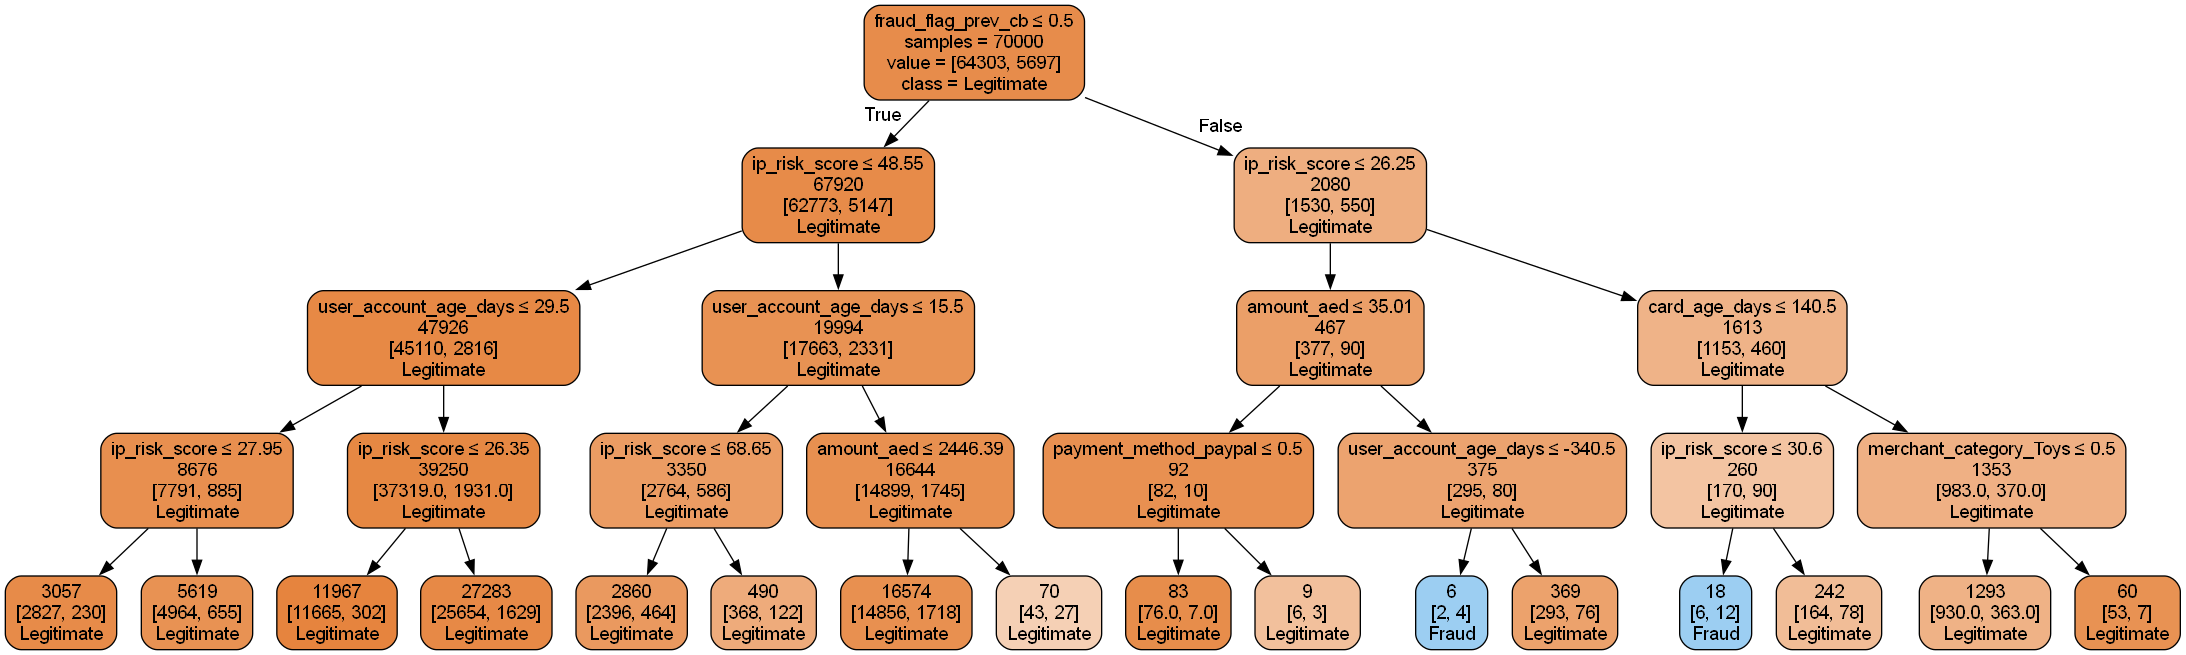

In [9]:
fraudTree = DecisionTreeClassifier(random_state=0, max_depth=4)
fraudTree.fit(train_X, train_y)

print("Number of nodes:", fraudTree.tree_.node_count)

plotDecisionTree(fraudTree, feature_names=train_X.columns, class_names=['Legitimate', 'Fraud'])

### Insight — Initial Decision Tree

**What "depth" means in plain terms:** a decision tree works by asking a 
series of yes/no questions about the data, each one narrowing down the 
group of transactions until it reaches a final answer of "Legitimate" or 
"Fraud." A shallow tree (depth = 4, used here) is a deliberately simplified 
first look to understand which variables the tree considers most important 
— not the final model.

**What this tree shows:** the very first and most important question the 
tree asks is whether `fraud_flag_prev_cb` is present. This is independently 
the same conclusion reached by SQL (where it had the highest fraud rate of 
any single flag) and by logistic regression (where it had the strongest 
statistical relationship to fraud). Three different analytical methods 
agreeing on the same answer is a meaningful confirmation, not a coincidence.

The next most important factor in both branches is `ip_risk_score`, again 
consistent with every prior phase of this analysis. After that, the tree 
relies on `user_account_age_days`, `amount_aed`, and `card_age_days`.

**On the open question from logistic regression:** `merchant_category_Toys` 
appears in this tree, but only at the very bottom after several other 
questions have already been asked. This suggests merchant category may carry 
a small amount of information in a narrow, specific context — not as a broad 
standalone signal. This is a more nuanced answer than logistic regression 
could provide.

**A limitation worth flagging clearly:** of the 16 final outcomes this tree 
can produce, only 2 are classified as "Fraud," applying to very small groups 
(6 and 18 transactions respectively). This happens because fraud is rare 
(8.21%) and a simple tree favors predicting the majority outcome almost 
everywhere. Addressing this class imbalance is necessary before this model 
could be considered usable, and is covered in the next section.

## Preprocessing — Handling Class Imbalance

This dataset has 91,789 legitimate transactions and only 8,211 fraud 
transactions (8.21%). Left as is, a model can achieve high accuracy simply 
by predicting "Legitimate" for almost everything, while still missing the 
majority of actual fraud — which is exactly the limitation shown by the 
initial decision tree.

Two common approaches exist to address this: class weighting (telling the 
model to penalize mistakes on the minority class more heavily, without 
changing the data itself) and oversampling (creating more examples of the 
minority class so the model sees a more balanced training set). 

Class weighting is simple to apply, but it is not consistently supported 
across all four models in this project — KNN in particular does not have 
a direct equivalent, since it does not use a training penalty in the same 
way Logistic Regression and tree-based models do.

SMOTE (Synthetic Minority Oversampling Technique) was chosen instead, since 
it works at the data level rather than the model level, meaning it can be 
applied once and used consistently across all four models for a fair 
comparison. SMOTE creates new, synthetic fraud examples by interpolating 
between existing real fraud cases, rather than simply duplicating them, so 
the model is exposed to a wider variety of fraud patterns during training.

SMOTE is applied only to the training set, never the test set. Testing 
must always happen on real, unaltered data to give an honest measure of 
how the model performs on transactions it has not seen before.

In [10]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=1)
train_X_smote, train_y_smote = smote.fit_resample(train_X, train_y)

print("Before SMOTE:", train_y.value_counts().to_dict())
print("After SMOTE:", train_y_smote.value_counts().to_dict())

Before SMOTE: {0: 64303, 1: 5697}
After SMOTE: {0: 64303, 1: 64303}


### Insight — SMOTE Applied

Before SMOTE, the training set had 64,303 legitimate transactions and only 
5,697 fraud transactions — a ratio of roughly 11 to 1. After SMOTE, both 
classes have 64,303 examples, a perfectly balanced training set.

This balance exists only in the training data. The validation set remains untouched, at its original real-world ratio, since the model must be evaluated on data that reflects how fraud actually occurs, not on an artificially balanced version. Training on balanced data while validating on real, imbalanced data is the standard approach — it gives the model a fair chance to learn fraud patterns without misrepresenting how well it will perform in practice.

### Decision Tree on SMOTE-Balanced Data
*Does training on balanced data change which fraud cases the tree identifies, compared to the original imbalanced tree?*

Number of nodes: 31


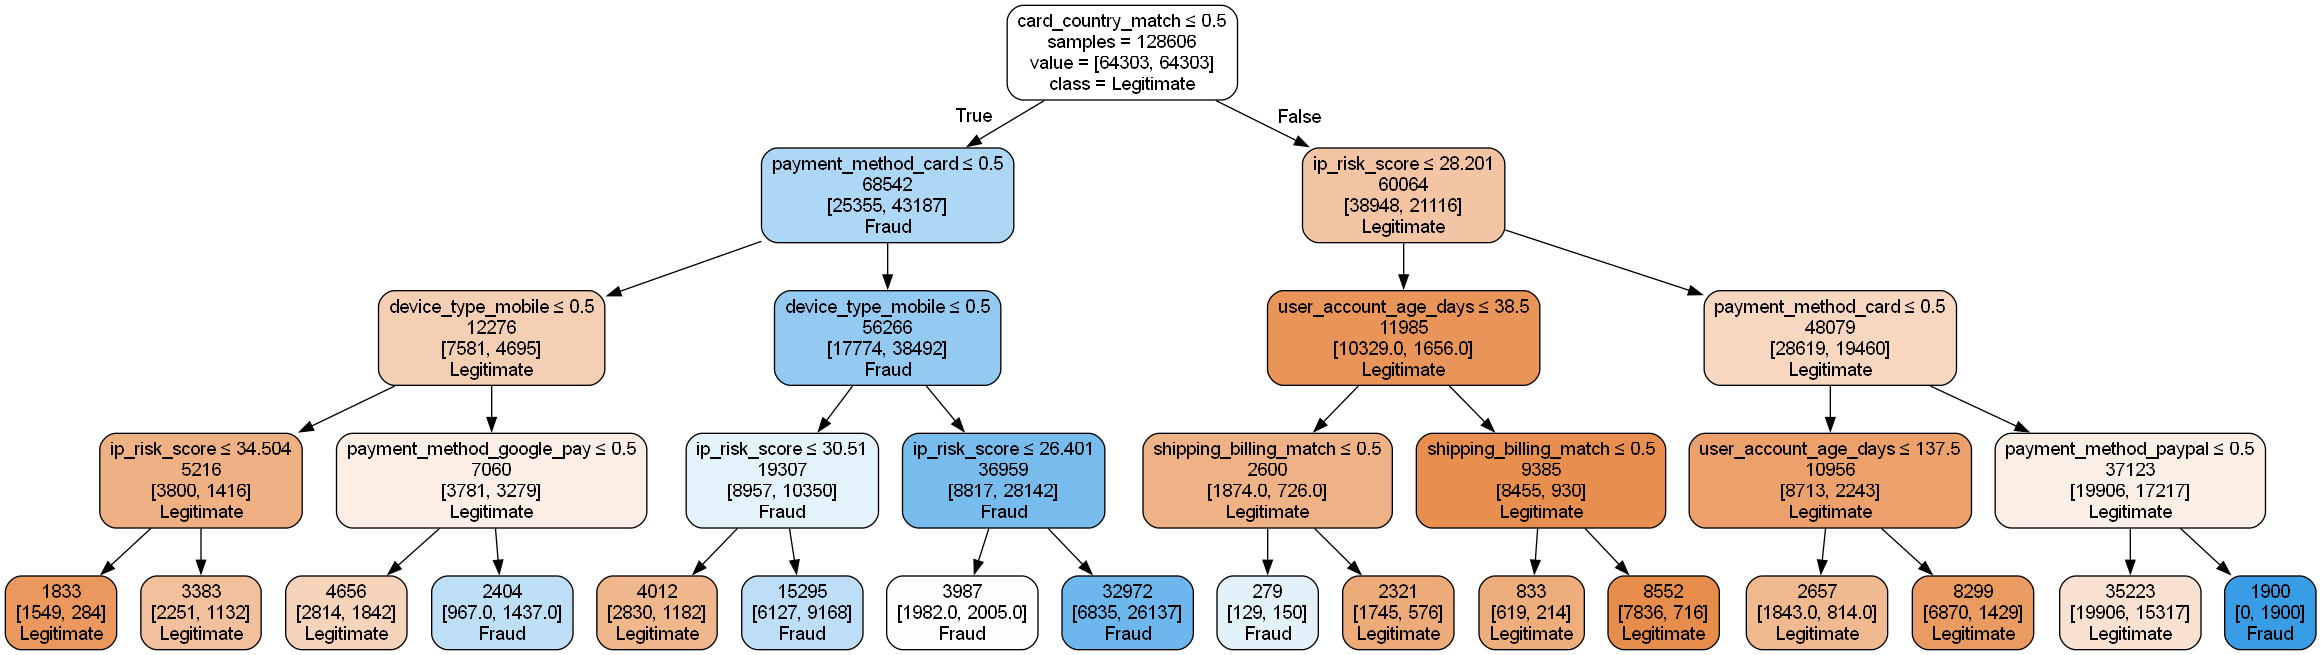

In [11]:
fraudTree_smote = DecisionTreeClassifier(random_state=0, max_depth=4)
fraudTree_smote.fit(train_X_smote, train_y_smote)

print("Number of nodes:", fraudTree_smote.tree_.node_count)

plotDecisionTree(fraudTree_smote, feature_names=train_X_smote.columns, class_names=['Legitimate', 'Fraud'])

### Checking SMOTE's Effect on Boolean Flag Columns
*Did SMOTE's interpolation distort the boolean flag columns, given that interpolating between two binary values can produce a fractional result?*

In [12]:
boolean_cols = ['user_is_high_risk', 'fraud_flag_prev_cb', 'fraud_flag_new_account', 
                 'fraud_flag_ip', 'card_country_match', 'shipping_billing_match', 
                 'odd_hour', 'payment_method_card', 'device_type_mobile']

print("Unique values BEFORE SMOTE:")
for col in boolean_cols:
    print(f"{col}: {sorted(train_X[col].unique())}")

print("\nUnique values AFTER SMOTE:")
for col in boolean_cols:
    unique_vals = sorted(train_X_smote[col].unique())
    print(f"{col}: {unique_vals[:5]}{'...' if len(unique_vals) > 5 else ''} ({len(unique_vals)} unique values)")

Unique values BEFORE SMOTE:
user_is_high_risk: [np.int64(0), np.int64(1)]
fraud_flag_prev_cb: [np.int64(0), np.int64(1)]
fraud_flag_new_account: [np.int64(0), np.int64(1)]
fraud_flag_ip: [np.int64(0), np.int64(1)]
card_country_match: [np.int64(0), np.int64(1)]
shipping_billing_match: [np.int64(0), np.int64(1)]
odd_hour: [np.int64(0), np.int64(1)]
payment_method_card: [np.False_, np.True_]
device_type_mobile: [np.False_, np.True_]

Unique values AFTER SMOTE:
user_is_high_risk: [np.int64(0), np.int64(1)] (2 unique values)
fraud_flag_prev_cb: [np.int64(0), np.int64(1)] (2 unique values)
fraud_flag_new_account: [np.int64(0), np.int64(1)] (2 unique values)
fraud_flag_ip: [np.int64(0), np.int64(1)] (2 unique values)
card_country_match: [np.int64(0), np.int64(1)] (2 unique values)
shipping_billing_match: [np.int64(0), np.int64(1)] (2 unique values)
odd_hour: [np.int64(0), np.int64(1)] (2 unique values)
payment_method_card: [np.False_, np.True_] (2 unique values)
device_type_mobile: [np.False_

### Insight — SMOTE Boolean Distortion Check

The original decision tree (built on imbalanced data) split first on 
`fraud_flag_prev_cb`, consistent with every prior method in this project — 
SQL, EDA, and logistic regression all identified it as the strongest 
single signal. The tree built on SMOTE-balanced data did not use this 
variable at all, splitting instead on `card_country_match`, 
`payment_method_card`, and `device_type_mobile`.

This was investigated further before drawing any conclusion, since SMOTE 
works by creating synthetic examples through interpolation between real 
data points, and boolean columns (which can only be 0 or 1) are not 
naturally suited to interpolation — a synthetic value halfway between a 0 
and a 1 would technically be 0.5, which has no real meaning for a flag 
that is either present or not present. If this were happening, it could 
explain why `fraud_flag_prev_cb` lost importance: its true signal could 
have been diluted by synthetic examples with weakened or unclear flag values.

Checking the boolean columns directly before and after SMOTE showed that 
every one remained cleanly 0/1 (or True/False), with no fractional values 
introduced. This rules out boolean distortion as the explanation for 
`fraud_flag_prev_cb` disappearing from the tree.

The more likely explanation, though not yet confirmed, is that balancing 
the training data gave the tree more room to explore splits on variables 
that may have been overshadowed before, when fraud represented only 8% of 
the training data. It is also possible that a single decision tree is 
simply sensitive to which of several similarly useful variables happens 
to be selected for the very first split, and that this sensitivity can 
shift when the underlying class balance changes, even if multiple 
variables are reasonably informative. 

This remains an open question rather than a settled one. Random Forest, 
which builds many trees on different random samples of the data and 
averages their results, will provide a more stable test of whether 
`fraud_flag_prev_cb` has genuinely lost importance under SMOTE-balanced 
data, or whether this particular tree simply found one of several 
reasonable paths through the data.

## Decision Tree — Unrestricted Model
*How does a fully grown tree perform on both the original and SMOTE-balanced training data?*

In [13]:
# Unrestricted tree on original imbalanced data
fraudTree_full = DecisionTreeClassifier(random_state=0)
fraudTree_full.fit(train_X, train_y)

print("Unrestricted tree — original data")
print(f"Number of nodes: {fraudTree_full.tree_.node_count}")
print(f"Max depth reached: {fraudTree_full.get_depth()}")
print("\nTraining set performance:")
classificationSummary(train_y, fraudTree_full.predict(train_X))
print("\nValidation set performance:")
classificationSummary(valid_y, fraudTree_full.predict(valid_X))

Unrestricted tree — original data
Number of nodes: 15433
Max depth reached: 44

Training set performance:
Confusion Matrix (Accuracy 1.0000)

       Prediction
Actual     0     1
     0 64303     0
     1     0  5697

Validation set performance:
Confusion Matrix (Accuracy 0.8436)

       Prediction
Actual     0     1
     0 24960  2526
     1  2166   348


In [14]:
# Unrestricted tree on SMOTE balanced data
fraudTree_full_smote = DecisionTreeClassifier(random_state=0)
fraudTree_full_smote.fit(train_X_smote, train_y_smote)

print("Unrestricted tree — SMOTE balanced data")
print(f"Number of nodes: {fraudTree_full_smote.tree_.node_count}")
print(f"Max depth reached: {fraudTree_full_smote.get_depth()}")
print("\nTraining set performance:")
classificationSummary(train_y_smote, fraudTree_full_smote.predict(train_X_smote))
print("\nValidation set performance:")
classificationSummary(valid_y, fraudTree_full_smote.predict(valid_X))

Unrestricted tree — SMOTE balanced data
Number of nodes: 23993
Max depth reached: 42

Training set performance:
Confusion Matrix (Accuracy 1.0000)

       Prediction
Actual     0     1
     0 64303     0
     1     0 64303

Validation set performance:
Confusion Matrix (Accuracy 0.8096)

       Prediction
Actual     0     1
     0 23829  3657
     1  2055   459


### Insight — Unrestricted Decision Tree

Both unrestricted trees — built on the original imbalanced data and the 
SMOTE-balanced data — grew extremely deep (44 and 42 levels respectively, 
with over 15,000 and 23,000 nodes) and achieved perfect accuracy on their 
training data. On the validation set, both performed significantly worse.

Comparing the two directly on the validation set:

| | Original (imbalanced) | SMOTE (balanced) |
|---|---|---|
| Overall accuracy | 84.36% | 80.96% |
| Fraud caught (recall) | 348 of 2,514 (13.8%) | 459 of 2,514 (18.3%) |
| Legitimate wrongly flagged | 2,526 | 3,657 |
| Nodes | 15,433 | 23,993 |
| Max depth | 44 | 42 |

This gap between perfect training performance and weaker validation 
performance is a classic sign of overfitting — the trees memorized every 
transaction in the training set rather than learning patterns that 
generalize to new, unseen transactions. A tree that has memorized its 
training data is not useful in practice, since the risk team would be 
applying it to transactions it has never seen before.

SMOTE improved recall from 13.8% to 18.3% — the model catches more actual 
fraud when trained on balanced data. However it also increased false 
positives from 2,526 to 3,657 — more legitimate customers are wrongly 
flagged. This is the fundamental fraud detection tradeoff: catching more 
fraud means accepting more false alarms. Neither version is usable as is.

Both trees need to be pruned — restricted from growing too deep — so they 
learn generalizable patterns rather than memorizing training examples. 
GridSearchCV is used in the next section to find the depth and pruning 
parameters that produce the best generalizable performance, tested through 
5-fold cross-validation rather than on the training data itself.

### Decision Tree — GridSearchCV Tuning
*What depth produces the best generalizable performance rather than memorizing the training data?*

In [16]:
# GridSearchCV on original imbalanced data
param_grid = {'max_depth': list(range(2, 20)), 
              'min_impurity_decrease': [0, 0.0005, 0.001, 0.005],
              'min_samples_split': [10, 20, 30, 40, 50]}

gridSearch = GridSearchCV(DecisionTreeClassifier(random_state=0), 
                          param_grid, cv=5, scoring='recall')
gridSearch.fit(train_X, train_y)

print("Best parameters — original data:")
print(gridSearch.best_params_)
print(f"Best cross-validated recall: {gridSearch.best_score_:.4f}")

Best parameters — original data:
{'max_depth': 19, 'min_impurity_decrease': 0, 'min_samples_split': 10}
Best cross-validated recall: 0.0697


### Insight — GridSearchCV on Original Imbalanced Data

GridSearchCV identified `max_depth=19`, no minimum impurity decrease, and 
a minimum of 10 samples to split as the best parameter combination for the 
original imbalanced training data. Despite these being the best available 
parameters, the cross-validated recall was only 6.97% — meaning the model 
correctly identifies less than 7 in every 100 actual fraud cases on average 
across the 5 validation folds.

This is not a tuning failure — it is the class imbalance problem surfacing 
at the cross-validation level. When GridSearchCV splits the training data 
into 5 folds for evaluation, each fold inherits the same severe imbalance 
present in the original data — roughly 91% legitimate transactions and 9% 
fraud. In that environment, the model consistently finds that predicting 
"Legitimate" for the majority of transactions is the path of least 
resistance, even when recall is the metric being optimized, because the 
fraud signal is too weak relative to the volume of legitimate transactions 
for the tree to consistently learn from it.

This confirms that class balance during training is the binding constraint, 
not tree depth or pruning parameters alone. However, simply applying SMOTE 
to the full training set before running GridSearchCV introduces a different 
problem — data leakage — where synthetic fraud examples created by SMOTE 
end up in both the training and validation folds during cross-validation, 
causing recall estimates to be artificially optimistic and not reflective 
of real-world performance.

The correct approach is to apply SMOTE inside each cross-validation fold, 
so that only the training portion of each fold is balanced while the 
validation portion always remains real, unaltered data. This is implemented 
using a Pipeline in the next section, which chains SMOTE and the Decision 
Tree together so GridSearchCV applies them in the correct order automatically.

## Decision Tree — Pipeline with SMOTE Inside Cross-Validation
*Does applying SMOTE correctly inside each cross-validation fold produce a more honest and reliable recall estimate?*

In [17]:
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=1)),
    ('tree', DecisionTreeClassifier(random_state=0))
])

param_grid_pipe = {
    'tree__max_depth': list(range(2, 20)),
    'tree__min_impurity_decrease': [0, 0.0005, 0.001, 0.005],
    'tree__min_samples_split': [10, 20, 30, 40, 50]
}

gridSearch_pipe = GridSearchCV(pipeline, param_grid_pipe, cv=5, scoring='recall')
gridSearch_pipe.fit(train_X, train_y)

print("Best parameters — Pipeline with SMOTE inside CV:")
print(gridSearch_pipe.best_params_)
print(f"Best cross-validated recall: {gridSearch_pipe.best_score_:.4f}")

Best parameters — Pipeline with SMOTE inside CV:
{'tree__max_depth': 3, 'tree__min_impurity_decrease': 0, 'tree__min_samples_split': 10}
Best cross-validated recall: 0.3505


In [18]:
# Build final Decision Tree using best Pipeline parameters
fraudTree_final = DecisionTreeClassifier(random_state=0,
                                          max_depth=3,
                                          min_impurity_decrease=0,
                                          min_samples_split=10)

# Train on SMOTE balanced data using best parameters
smote_final = SMOTE(random_state=1)
train_X_final, train_y_final = smote_final.fit_resample(train_X, train_y)

fraudTree_final.fit(train_X_final, train_y_final)

print("Final Decision Tree — Pipeline parameters")
print(f"Number of nodes: {fraudTree_final.tree_.node_count}")
print(f"Max depth: {fraudTree_final.get_depth()}")
print("\nTraining set performance:")
classificationSummary(train_y_final, fraudTree_final.predict(train_X_final))
print("\nValidation set performance:")
classificationSummary(valid_y, fraudTree_final.predict(valid_X))

Final Decision Tree — Pipeline parameters
Number of nodes: 15
Max depth: 3

Training set performance:
Confusion Matrix (Accuracy 0.6611)

       Prediction
Actual     0     1
     0 46529 17774
     1 25811 38492

Validation set performance:
Confusion Matrix (Accuracy 0.6931)

       Prediction
Actual     0     1
     0 19943  7543
     1  1663   851


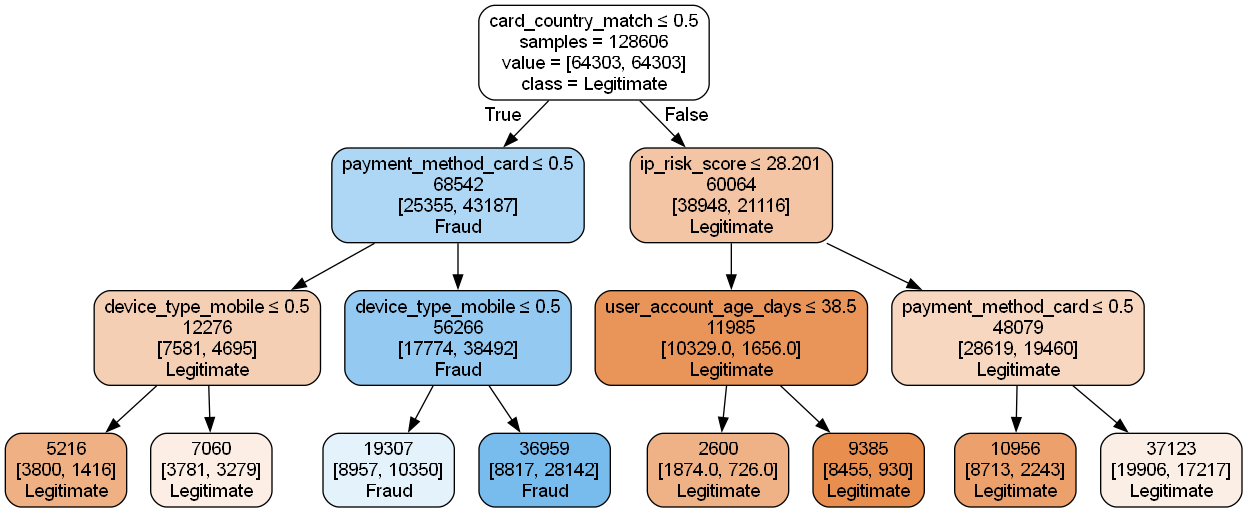

In [19]:
plotDecisionTree(fraudTree_final, 
                 feature_names=train_X.columns, 
                 class_names=['Legitimate', 'Fraud'])

### Insight — Final Decision Tree (Pipeline with SMOTE Inside Cross-Validation)

**The result**

The Pipeline approach — applying SMOTE inside each cross-validation fold 
rather than to the full training set upfront — produced a cross-validated 
recall of 35.05%, and the final model achieved 33.8% recall on the real, 
unaltered validation set. The gap between these two numbers (35.05% vs 
33.8%) is small, which suggests the Pipeline produced a more honest and 
reliable performance estimate than the earlier approach, where the gap 
was 80.65% vs 12.6%.

The final tree has only 15 nodes and a maximum depth of 3 — a very simple 
model. This simplicity is itself a finding: when SMOTE is applied correctly 
and validation folds reflect real fraud distributions, GridSearchCV 
determined that a shallow tree generalizes better than a deep one for this 
problem.

**The performance tradeoff**

On the validation set, the final tree caught 851 of 2,514 actual fraud 
cases (33.8% recall) while incorrectly flagging 7,543 legitimate 
transactions as fraud. Overall accuracy was 69.3%.

Comparing all Decision Tree versions:

| Version | Recall | False Positives | Accuracy |
|---|---|---|---|
| Unrestricted — original | 13.8% | 2,526 | 84.4% |
| Unrestricted — SMOTE | 18.3% | 3,657 | 81.0% |
| Pipeline — final model | 33.8% | 7,543 | 69.3% |

The Pipeline version catches the most fraud of any Decision Tree tested, 
but at the cost of more false positives — more legitimate customers 
incorrectly flagged. This is the fundamental fraud detection tradeoff 
made visible: catching more fraud means accepting more false alarms. 
Whether that balance is acceptable depends on what the risk team is 
willing to tolerate in terms of customer friction, and is a business 
decision rather than a modelling one.

**On fraud_flag_prev_cb not appearing in the final tree**

Throughout this project — in SQL, EDA, and logistic regression — 
`fraud_flag_prev_cb` consistently appeared as the strongest signal. 
It does not appear anywhere in the final Decision Tree's splits. 
This is acknowledged here as an open question rather than ignored — 
boolean distortion from SMOTE was checked directly and ruled out, 
and multicollinearity was confirmed low via VIF. A more grounded 
explanation based on verified numbers is developed in the Random 
Forest section, where feature importance across 500 trees provides 
a more stable basis for drawing conclusions than a single tree alone.

**What this means going into Random Forest**

The Decision Tree, even with correct SMOTE application, catches 
roughly 1 in 3 actual fraud cases — missing the majority. It also 
generates a high volume of false positives relative to the fraud 
it catches. A single decision tree is known to be sensitive to the 
specific transactions it trains on, which can limit how well it 
generalizes to new data.

Random Forest addresses this by building many trees on different 
random samples of the data and combining their results, which tends 
to produce more stable performance than any single tree. It also 
produces feature importance scores — a direct, quantitative measure 
of which variables each tree found most useful — which may help 
shed further light on the `fraud_flag_prev_cb` question and on 
whether the variables the Decision Tree preferred are consistently 
more useful across many trees, or whether this was specific to 
the conditions of this one model.

## Random Forest Classifier
*Does an ensemble of many decision trees produce more stable and generalizable fraud detection than a single tree?*

In [20]:
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest using Pipeline with SMOTE inside CV
pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=1)),
    ('rf', RandomForestClassifier(n_estimators=500, random_state=1))
])

param_grid_rf = {
    'rf__max_depth': [5, 10, 15, 20, None],
    'rf__min_samples_split': [10, 20, 30],
    'rf__max_features': ['sqrt', 'log2']
}

gridSearch_rf = GridSearchCV(pipeline_rf, param_grid_rf, 
                              cv=5, scoring='recall', n_jobs=-1)
gridSearch_rf.fit(train_X, train_y)

print("Best parameters — Random Forest Pipeline:")
print(gridSearch_rf.best_params_)
print(f"Best cross-validated recall: {gridSearch_rf.best_score_:.4f}")

Best parameters — Random Forest Pipeline:
{'rf__max_depth': 5, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 20}
Best cross-validated recall: 0.2905


In [21]:
# Build final Random Forest using best Pipeline parameters
rf_final = RandomForestClassifier(n_estimators=500, 
                                   max_depth=5,
                                   max_features='sqrt',
                                   min_samples_split=20,
                                   random_state=1)

smote_rf = SMOTE(random_state=1)
train_X_rf, train_y_rf = smote_rf.fit_resample(train_X, train_y)

rf_final.fit(train_X_rf, train_y_rf)

print("Final Random Forest performance:")
print("\nTraining set:")
classificationSummary(train_y_rf, rf_final.predict(train_X_rf))
print("\nValidation set:")
classificationSummary(valid_y, rf_final.predict(valid_X))

Final Random Forest performance:

Training set:
Confusion Matrix (Accuracy 0.7813)

       Prediction
Actual     0     1
     0 50157 14146
     1 13974 50329

Validation set:
Confusion Matrix (Accuracy 0.7397)

       Prediction
Actual     0     1
     0 21431  6055
     1  1755   759


                               feature  importance
5                   card_country_match    0.223615
24                 payment_method_card    0.144386
0                        ip_risk_score    0.128288
21                  device_type_mobile    0.114322
7                             odd_hour    0.055129
13       merchant_category_Electronics    0.044757
26               payment_method_paypal    0.039406
15         merchant_category_Groceries    0.037995
14           merchant_category_Fashion    0.035974
25           payment_method_google_pay    0.034813
6               shipping_billing_match    0.028422
12     merchant_category_Digital Goods    0.023761
23        payment_method_bank_transfer    0.022065
9                user_account_age_days    0.016743
11                         items_count    0.012640
3               fraud_flag_new_account    0.011350
17          merchant_category_Pharmacy    0.007440
22                  device_type_tablet    0.006006
16  merchant_category_Home & Fu

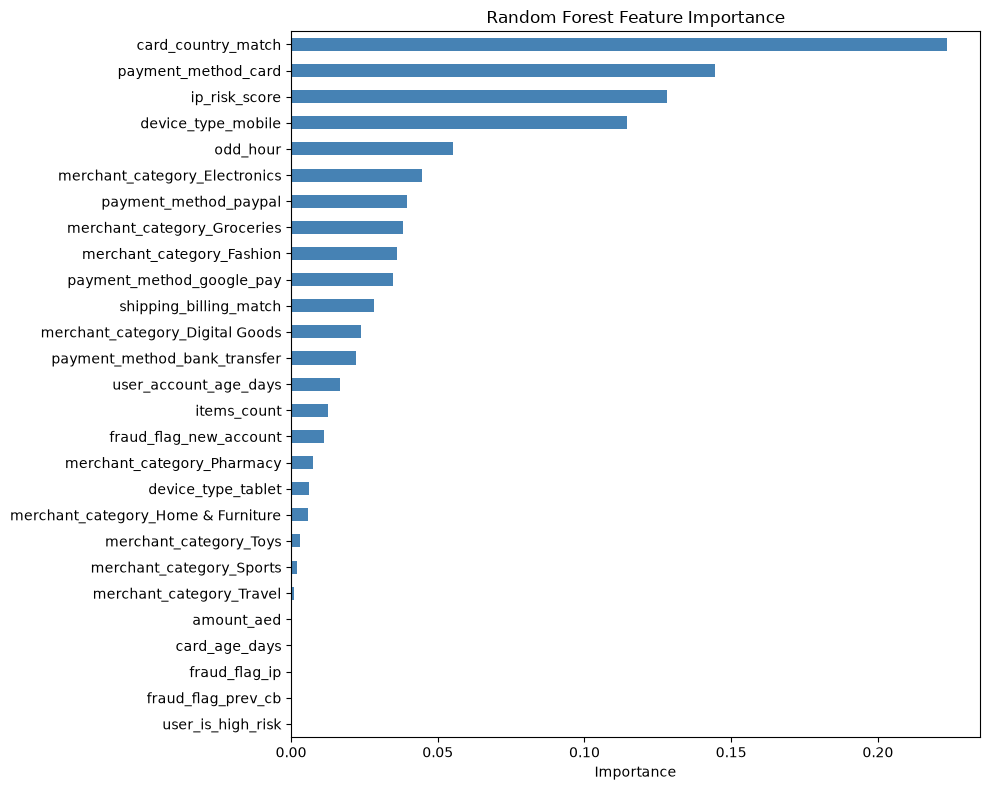

In [22]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': train_X.columns,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

feature_importance.sort_values('importance').plot(
    kind='barh', x='feature', y='importance',
    figsize=(10, 8), legend=False, color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

## Random Forest — Results and Feature Importance

### Model Performance

The final Random Forest model (500 trees, max_depth=5, max_features='sqrt', 
min_samples_split=20) was built using the same Pipeline approach as the 
Decision Tree — applying SMOTE inside each cross-validation fold to ensure 
honest performance estimates against real, unaltered validation data.

Results on the validation set:

| | Decision Tree Pipeline | Random Forest Pipeline |
|---|---|---|
| Cross-validated recall | 35.05% | 29.05% |
| Actual validation recall | 33.8% | 30.2% |
| False positives | 7,543 | 6,055 |
| Accuracy | 69.3% | 74.0% |

Random Forest produced fewer false positives (6,055 vs 7,543) and higher 
overall accuracy (74.0% vs 69.3%) than the Decision Tree, but slightly 
lower recall (30.2% vs 33.8%). Neither model is clearly superior — the 
better choice depends on what the risk team prioritizes. If catching more 
fraud is the primary goal, the Decision Tree Pipeline edges ahead. If 
reducing unnecessary friction for legitimate customers matters more, 
Random Forest is the slightly better option.

The gap between cross-validated recall (29.05%) and actual validation 
recall (30.2%) is small — and notably, actual performance slightly 
exceeded the cross-validated estimate rather than falling below it. 
This suggests the Pipeline is producing honest, reliable estimates, 
consistent with what was seen in the Decision Tree Pipeline results.

### Feature Importance

The feature importance ranking reveals a pattern that is both surprising 
and consistent with what the Decision Tree found — and is now confirmed 
across 500 trees rather than just one, making it harder to attribute to 
any single model's quirk.

The top four variables by importance are `card_country_match` (0.224), 
`payment_method_card` (0.144), `ip_risk_score` (0.128), and 
`device_type_mobile` (0.114). The variables that SQL and EDA identified 
as the strongest individual signals — `fraud_flag_prev_cb` (0.000145) 
and `user_is_high_risk` (0.000062) — appear at the very bottom of the 
ranking, with importance scores close to zero.

**On fraud_flag_prev_cb scoring near zero**

This finding has now been observed consistently across the Decision Tree 
and Random Forest, making it more stable than a single model result. 
Checking the data directly provides a more grounded explanation than 
was available earlier.

Of the 2,981 transactions where `fraud_flag_prev_cb` fires, 812 are 
confirmed fraud and 2,169 are legitimate — meaning the flag fires on 
more than twice as many legitimate transactions as fraudulent ones in 
absolute terms. Of the 8,211 total fraud cases, only 812 (9.9%) have 
this flag present — the remaining 7,399 fraud cases (90.1%) occur 
without it.

This helps explain the low feature importance score. SQL measured the 
fraud rate among transactions where the flag fires (812 out of 2,981 = 
27.24%) — a precision measure that is genuinely high. Random Forest 
feature importance measures how useful a variable is for splitting 
large groups of transactions across all 500 trees. A variable that 
fires on more legitimate transactions than fraud transactions in 
absolute terms may create a noisier split for a model trying to 
classify the full dataset, even if it is highly reliable in the 
specific cases where it applies. This is offered as the most 
plausible explanation based on the data checked, not a confirmed cause.

Both findings are consistent with each other and with the data: 
`fraud_flag_prev_cb` is a high precision, low coverage signal — 
very reliable when present, but present in only a small and 
unrepresentative slice of fraud cases. These are two different 
analytical questions with two different correct answers, and the 
apparent contradiction between SQL and Random Forest becomes more 
understandable once that distinction is made clear.

**On the categorical variables appearing strongly**

`payment_method_card`, `device_type_mobile`, and several merchant 
category dummies score meaningfully in feature importance — consistent 
with what the Decision Tree found, and continuing to present a picture 
that differs from the SQL signal ranking. The most plausible explanation, 
held as a hypothesis rather than a conclusion, is that SQL tested each 
variable independently while Random Forest captures their combined, 
interactive contribution across 500 trees. A variable that appears weak 
in isolation may carry meaningful signal in combination with others — 
something a univariate SQL analysis is not designed to detect. This 
remains an open question that further analysis could explore.

**On user_is_high_risk scoring near zero**

`user_is_high_risk` scored the lowest of all variables at 0.000062, 
despite having a 22.07% fraud rate in SQL. A similar explanation 
applies — high risk users account for only 4,871 of 100,000 transactions, 
and of those, 1,075 are confirmed fraud. Like `fraud_flag_prev_cb`, 
this is a high precision, low coverage signal that fires rarely enough 
that Random Forest's trees may rarely encounter it in their random 
training samples, limiting its contribution to feature importance 
regardless of how reliable it is when it fires.

### What This Means Going into KNN

Both tree-based models — the Decision Tree and Random Forest — have 
produced broadly consistent findings: recall in the range of 30-34%, 
moderate false positive rates, and a feature importance ranking that 
diverges meaningfully from the SQL signal ranking. Neither model is 
strong enough to be used as a standalone fraud detector, but both 
have identified real patterns worth carrying into the final model 
comparison.

KNN takes a fundamentally different approach — rather than building 
rules or splitting on thresholds, it classifies a transaction by 
finding the most similar transactions in the training data and 
predicting based on their outcomes. This directly addresses the 
context-sensitivity limitation identified in SQL Section G, where 
39.65% of fraud occurred in transactions with zero flags fired. 
Whether KNN's similarity-based approach produces meaningfully 
different results from the rule-based tree models is the next 
question to test.

## KNN Classifier (K-Nearest Neighbors)
*Does a similarity-based approach identify fraud patterns that rule-based tree models missed, particularly in zero-flag transactions?*

### Step 1 — Normalize Features
KNN measures distance between transactions numerically. Without normalization, 
variables with large numeric ranges (like amount_aed, up to 29,000 AED) would 
dominate the distance calculation simply because their numbers are larger — 
not because they are more important. StandardScaler puts all variables on the 
same scale so distance is measured fairly across all features.

The scaler is fit on the training data only and then applied to both training 
and validation sets. Fitting on validation data too would constitute data 
leakage — the scaler would have seen information from the validation set 
during training.

In [23]:
from sklearn.preprocessing import StandardScaler

# Normalize using training data only
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
valid_X_scaled = scaler.transform(valid_X)

print("Training set scaled shape:", train_X_scaled.shape)
print("Validation set scaled shape:", valid_X_scaled.shape)
print("\nMean of first 3 features after scaling (should be close to 0):")
print(train_X_scaled[:, :3].mean(axis=0))

Training set scaled shape: (70000, 27)
Validation set scaled shape: (30000, 27)

Mean of first 3 features after scaling (should be close to 0):
[-2.5254719e-16 -2.4158453e-17  4.0602442e-17]


### Step 2 — Apply SMOTE to Scaled Training Data
SMOTE is applied to the scaled training data so the synthetic fraud examples  are generated in the same normalized feature space that KNN will use for distance calculations. Applying SMOTE before scaling or after scaling produces different results — applying it after scaling is the correct order here since KNN operates in the scaled space.

In [24]:
smote_knn = SMOTE(random_state=1)
train_X_knn, train_y_knn = smote_knn.fit_resample(train_X_scaled, train_y)

print("Before SMOTE:", train_y.value_counts().to_dict())
print("After SMOTE:", pd.Series(train_y_knn).value_counts().to_dict())

Before SMOTE: {0: 64303, 1: 5697}
After SMOTE: {0: 64303, 1: 64303}


### Step 3 — Finding the Best K
*Which value of K produces the best recall on the validation set?*

K controls how many neighboring transactions the model consults before 
making a prediction. A small K is sensitive to local patterns but noisy. 
A large K is smoother but may miss local fraud clusters. Rather than 
guessing, we test a range of K values and pick the one that produces 
the best recall on the validation set — consistent with our evaluation 
priority of catching as much fraud as possible.

In [26]:
k_values = list(range(1, 20)) + list(range(20, 100, 5)) + list(range(100, 370, 20))

results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_X_knn, train_y_knn)
    pred = knn.predict(valid_X_scaled)
    
    true_positive = ((pred == 1) & (valid_y == 1)).sum()
    actual_positive = (valid_y == 1).sum()
    recall = true_positive / actual_positive
    accuracy = (pred == valid_y).mean()
    
    results.append({'k': k, 'recall': recall, 'accuracy': accuracy})
    print(f"k={k:3d} | Recall: {recall:.4f} | Accuracy: {accuracy:.4f}")

results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['recall'].idxmax(), 'k']
print(f"\nBest K by recall: {best_k}")

k=  1 | Recall: 0.1961 | Accuracy: 0.7993
k=  2 | Recall: 0.1659 | Accuracy: 0.8219
k=  3 | Recall: 0.2908 | Accuracy: 0.7460
k=  4 | Recall: 0.2649 | Accuracy: 0.7693
k=  5 | Recall: 0.3663 | Accuracy: 0.7074
k=  6 | Recall: 0.3381 | Accuracy: 0.7292
k=  7 | Recall: 0.4200 | Accuracy: 0.6759
k=  8 | Recall: 0.3930 | Accuracy: 0.6976
k=  9 | Recall: 0.4515 | Accuracy: 0.6518
k= 10 | Recall: 0.4288 | Accuracy: 0.6728
k= 11 | Recall: 0.4809 | Accuracy: 0.6336
k= 12 | Recall: 0.4578 | Accuracy: 0.6536
k= 13 | Recall: 0.5068 | Accuracy: 0.6199
k= 14 | Recall: 0.4773 | Accuracy: 0.6388
k= 15 | Recall: 0.5219 | Accuracy: 0.6056
k= 16 | Recall: 0.4968 | Accuracy: 0.6265
k= 17 | Recall: 0.5430 | Accuracy: 0.5967
k= 18 | Recall: 0.5159 | Accuracy: 0.6175
k= 19 | Recall: 0.5557 | Accuracy: 0.5907
k= 20 | Recall: 0.5282 | Accuracy: 0.6110
k= 25 | Recall: 0.5843 | Accuracy: 0.5753
k= 30 | Recall: 0.5752 | Accuracy: 0.5862
k= 35 | Recall: 0.6126 | Accuracy: 0.5585
k= 40 | Recall: 0.6134 | Accuracy:

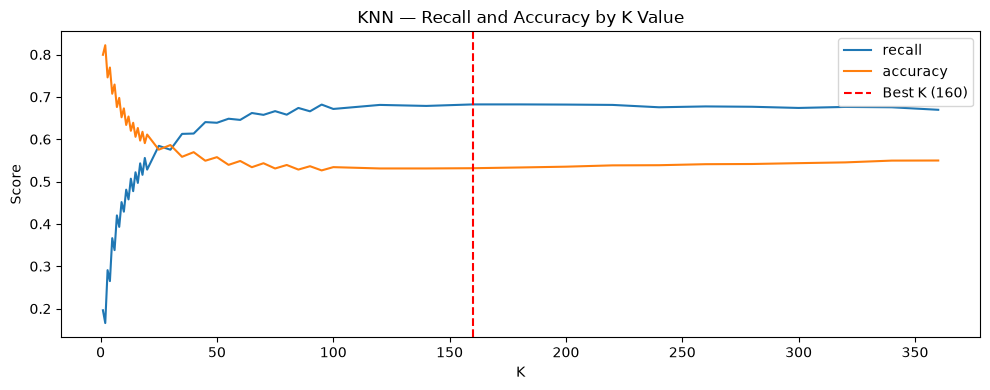

In [27]:
# Plot recall and accuracy across K values
results_df.plot(x='k', y=['recall', 'accuracy'], figsize=(10, 4))
plt.title('KNN — Recall and Accuracy by K Value')
plt.xlabel('K')
plt.ylabel('Score')
plt.axvline(x=160, color='red', linestyle='--', label='Best K (160)')
plt.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150)
plt.show()

In [28]:
knn_final = KNeighborsClassifier(n_neighbors=160)
knn_final.fit(train_X_knn, train_y_knn)

print("Final KNN Model — k=160")
print("\nValidation set performance:")
classificationSummary(valid_y, knn_final.predict(valid_X_scaled))

Final KNN Model — k=160

Validation set performance:
Confusion Matrix (Accuracy 0.5315)

       Prediction
Actual     0     1
     0 14231 13255
     1   799  1715


## KNN — Results and K Selection

### K Selection

The K-selection loop tested values from k=1 to k=360, guided by the 
√n rule of thumb which suggests K ≈ √(training set size) as a reasonable 
upper bound. With 128,606 SMOTE-balanced training rows, √128,606 ≈ 359, 
making the textbook range of 1-20 far too conservative for a dataset 
of this size.

The chart confirms this — recall at k=19 was only 55.6%, while the 
model's natural ceiling sits around 68%, only reached by testing into 
the higher K range. Stopping at k=20 would have significantly 
underestimated KNN's capability on this dataset.

Recall rises steeply from k=1 to around k=30, then continues rising 
more gradually before plateauing at approximately 68% from k=95 onwards. 
The plateau suggests the model has found its natural ceiling for this 
dataset and feature set — adding more neighbors beyond this point adds 
noise rather than signal. k=160 was selected as the best K by recall, 
though the difference between k=95 and k=160 is negligible (less than 
0.5 percentage points), and a smaller K would be preferable in a 
production setting where computation time matters.

Accuracy moves in the opposite direction — starting high at small K 
values and declining as K increases, stabilizing around 54-55% from 
k=100 onwards. This inverse relationship between recall and accuracy 
is consistent with what was observed across all models in this project 
and reflects the fundamental fraud detection tradeoff: catching more 
fraud means flagging more legitimate transactions.

### Model Performance

The final KNN model (k=160, trained on SMOTE-balanced scaled data) 
achieved the following on the real, unaltered validation set:

- **Recall: 68.2%** — 1,715 of 2,514 actual fraud cases correctly identified
- **False positives: 13,255** — legitimate transactions incorrectly flagged
- **Overall accuracy: 53.15%**

KNN has the highest recall of any model tested in this project — catching 
more than twice as much fraud as the Decision Tree (33.8%) and Random 
Forest (30.2%). However it also generates the most false positives by 
a significant margin, flagging 13,255 legitimate transactions compared 
to 7,543 for the Decision Tree and 6,055 for Random Forest.

Overall accuracy of 53.15% sits below the 91.79% baseline of predicting 
every transaction as legitimate. This is not a meaningful concern on its 
own — as established throughout this project, overall accuracy is a 
misleading metric for imbalanced fraud detection problems. What matters 
is how much fraud the model catches and at what cost in false alarms.

### What This Means

KNN's stronger recall is consistent with its design — rather than 
building rules or splitting on thresholds, it classifies each transaction 
by finding the most similar transactions in the training data and 
predicting based on their outcomes. This approach may be better suited 
to detecting the contextual, combination-dependent fraud patterns that 
SQL Section G identified — where 39.65% of fraud occurs in transactions 
with zero individual flags fired. Whether KNN is genuinely detecting 
these zero-flag fraud cases more effectively than the tree models is 
worth examining in the model comparison section.

The tradeoff between recall and false positives across all three models 
is summarised in the next section, where the risk team recommendation 
is made based on the full picture rather than any single metric.

## Model Comparison and Risk Team Recommendation

*Across all four models tested, which performs best for fraud detection and what should the risk team actually do with these findings?*

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect predictions from all final models
models = {
    'Decision Tree': fraudTree_final.predict(valid_X),
    'Random Forest': rf_final.predict(valid_X),
    'KNN': knn_final.predict(valid_X_scaled)
}

results = []
for name, pred in models.items():
    results.append({
        'Model': name,
        'Recall': round(recall_score(valid_y, pred), 4),
        'Precision': round(precision_score(valid_y, pred), 4),
        'F1 Score': round(f1_score(valid_y, pred), 4),
        'False Positives': int(((pred == 1) & (valid_y == 0)).sum()),
        'Fraud Caught': int(((pred == 1) & (valid_y == 1)).sum()),
        'Accuracy': round((pred == valid_y).mean(), 4)
    })

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

        Model  Recall  Precision  F1 Score  False Positives  Fraud Caught  Accuracy
Decision Tree  0.3385     0.1014    0.1560             7543           851    0.6931
Random Forest  0.3019     0.1114    0.1627             6055           759    0.7397
          KNN  0.6822     0.1146    0.1962            13255          1715    0.5315


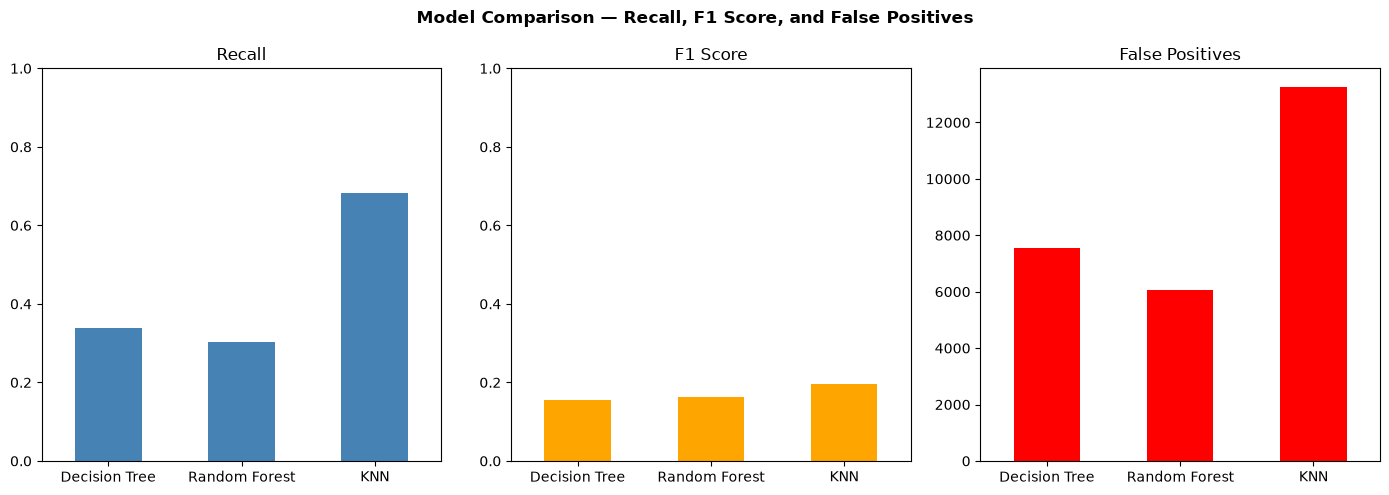

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Recall
comparison_df.plot(kind='bar', x='Model', y='Recall', 
                   ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Recall')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

# F1 Score
comparison_df.plot(kind='bar', x='Model', y='F1 Score', 
                   ax=axes[1], legend=False, color='orange')
axes[1].set_title('F1 Score')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 1)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

# False Positives
comparison_df.plot(kind='bar', x='Model', y='False Positives', 
                   ax=axes[2], legend=False, color='red')
axes[2].set_title('False Positives')
axes[2].set_xlabel('')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=0)

plt.suptitle('Model Comparison — Recall, F1 Score, and False Positives', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

### Insight — Model Comparison and Risk Team Recommendation

**Summary of results**

| Model | Recall | Precision | F1 Score | False Positives | Fraud Caught |
|---|---|---|---|---|---|
| Decision Tree | 33.9% | 10.1% | 0.156 | 7,543 | 851 |
| Random Forest | 30.2% | 11.1% | 0.163 | 6,055 | 759 |
| KNN | 68.2% | 11.5% | 0.196 | 13,255 | 1,715 |

Note: Logistic Regression was used in this project for statistical 
inspection and variable selection via p-values and coefficients rather 
than as a predictive model, and does not have comparable classification 
metrics. Its role was to test which variables were statistically 
significant before building the classification models.

**The honest overall assessment**

All three models have low F1 scores — 0.156, 0.163, and 0.196 
respectively. F1 score is the recommended metric for imbalanced 
classification problems because it balances precision and recall 
simultaneously, penalizing both missed fraud and excessive false alarms. 
Values this low confirm that none of these models are strong standalone 
fraud detectors by any rigorous standard.

Precision tells a similarly honest story — roughly 9 out of every 10 
fraud flags raised by any of these models is a false alarm. For a risk 
team, this means any of these models used in isolation would generate 
a very high volume of unnecessary interventions for legitimate customers.

**What each model does best**

KNN achieves the highest recall (68.2%) and the highest F1 score (0.196), 
catching 1,715 of 2,514 fraud cases — more than twice as many as the 
tree models. However it also generates the most false positives by a 
significant margin (13,255), meaning more than half of all legitimate 
transactions in the validation set were incorrectly flagged.

Random Forest achieves the lowest false positives (6,055) and the 
highest overall accuracy (74.0%), making it the most conservative 
option — it flags fewer transactions overall, but also catches the 
least fraud (759 cases, 30.2% recall).

Decision Tree sits between the two on most metrics without being 
clearly best at anything.

**The fundamental tradeoff**

The chart makes the core tradeoff visible — higher recall always comes 
with more false positives across all three models. There is no model 
here that catches significantly more fraud without also generating 
significantly more false alarms. This is a reflection of the dataset 
itself — as established in SQL Section G, fraud in this dataset does 
not follow simple, consistent patterns, with 39.65% of fraud occurring 
in transactions with zero flags fired.

**Risk team recommendation**

No single model from this analysis is recommended for standalone 
deployment as a fraud detection system. The F1 scores and precision 
levels across all three models suggest that the current feature set 
and available signals are not sufficient to build a reliable automated 
classifier without generating an unacceptable volume of false alarms.

However, the findings from this analysis do provide actionable guidance:

If the risk team's priority is catching as much fraud as possible 
and the operational capacity exists to review a high volume of flagged 
transactions, KNN at k=160 is the most suitable model — it catches 
68.2% of fraud, which is meaningfully better than the tree models, 
at the cost of a higher false positive rate.

If minimizing unnecessary customer friction and operational review 
burden is the priority, Random Forest is the more appropriate choice — 
it generates the fewest false positives while maintaining reasonable 
recall, and its feature importance output provides the most 
interpretable signal ranking for rule-based supplementation.

In practice, the most defensible approach for this dataset would 
likely be a hybrid system — using the rule-based signals identified 
in SQL (particularly prev_cb_flag, user_is_high_risk, and ip_risk_score) 
for high-confidence automatic interventions, while using the ML model 
as a second-layer scoring tool for transactions that fall below the 
rule-based threshold. This would address the coverage gap identified 
in SQL Section G without generating the false positive volume that 
comes with relying on ML alone.

**What this project found overall**

Three independent analytical methods — SQL signal testing, Python EDA, 
and ML classification — consistently identified ip_risk_score, 
geographic mismatch, and user risk profile as the most actionable 
signals. The ML phase also surfaced card_country_match, 
payment_method_card, and device_type as potentially more useful in 
combination than their individual SQL fraud rates suggested, which 
is worth investigating further with more sophisticated feature 
engineering or interaction terms in a future iteration.

The most important finding across all three phases remains the one 
identified in SQL Section G — 39.65% of fraud in this dataset occurs 
in transactions that trigger no existing flags and show no single 
obvious anomaly. Closing this coverage gap is the primary challenge 
for any fraud detection system built on this data, and it is a 
challenge that neither rule-based systems nor the models tested here 
have fully solved.

## Project Summary — UAE E-Commerce Fraud Signal Analysis

This project analyzed 100,000 synthetic UAE e-commerce transactions 
across three phases — SQL signal analysis, Python EDA, and ML 
classification — to identify which signals best predict fraudulent 
activity and how effectively a machine learning model can detect fraud 
in a real-world imbalanced dataset.

---

### What Each Phase Found

**Phase 1 — SQL**

Eight analytical sections tested eleven signals against confirmed fraud 
outcomes. Three signals emerged as strong predictors: prev_cb_flag 
(27.24% fraud rate when fired), user_is_high_risk (22.07%), and 
ip_flag (16.05%). Geographic mismatch and new_account_flag showed 
moderate predictive value. Categorical variables — merchant category, 
device type, and payment method — showed less than 1% fraud rate 
spread and appeared weak as standalone signals.

The most important SQL finding was in Section G: 39.65% of all fraud 
(3,256 of 8,211 cases) occurs in transactions with zero flags fired. 
This single finding established that rule-based detection alone cannot 
close the fraud coverage gap and justified the ML phase.

**Phase 2 — Python EDA**

Visualizations validated and extended the SQL findings. The transaction 
amount KDE chart contradicted the SQL average — fraudulent transactions 
actually cluster at lower amounts than legitimate ones, with the SQL 
average inflated by outliers. This demonstrated the value of 
distribution analysis over averages alone.

The correlation heatmap identified six redundant variable pairs, 
informing feature selection for the ML phase. The signal strength 
ranking chart consolidated all findings into a single prioritized 
visual for the risk team.

**Phase 3 — ML Classification**

Three classification models were built and evaluated using a Pipeline 
approach that correctly applies SMOTE inside each cross-validation 
fold to prevent data leakage — a methodological refinement discovered 
during this phase when an earlier approach produced optimistic recall 
estimates that did not hold on real validation data.

The ML phase also surfaced an important finding about the relationship 
between SQL signal rankings and model feature importance. Variables 
identified as the strongest signals in SQL — prev_cb_flag and 
user_is_high_risk — scored near zero in Random Forest feature 
importance, while categorical variables that appeared weak in SQL 
scored strongly. Direct investigation confirmed that prev_cb_flag 
fires on more legitimate transactions (2,169) than fraud ones (812) 
in absolute terms, making it a high precision but low coverage signal 
that behaves differently in a model optimizing across the full dataset 
versus a SQL analysis measuring fraud rate within a narrow firing 
group. This distinction between precision and breadth is one of the 
most practically useful findings in this project.

---

### Final Model Results

| Model | Recall | F1 Score | False Positives |
|---|---|---|---|
| Decision Tree | 33.9% | 0.156 | 7,543 |
| Random Forest | 30.2% | 0.163 | 6,055 |
| KNN | 68.2% | 0.196 | 13,255 |

All three models produced low F1 scores, confirming that the available 
signals are not sufficient to build a reliable standalone automated 
classifier without generating a high volume of false alarms. KNN 
achieved the highest recall and F1, making it the most suitable model 
if catching fraud is the primary priority. Random Forest generated 
the fewest false positives, making it preferable if minimizing 
customer friction matters more.

---

### Limitations

**Dataset** — this is a synthetic dataset. Some signals that would 
typically carry strong real-world signal — such as transaction velocity 
— showed no variation, likely due to how the data was generated. 
Findings should be validated against real transaction data before 
any production deployment.

**SMOTE and boolean features** — SMOTE was applied to a feature set 
that includes several boolean flag columns. While direct inspection 
confirmed that boolean values remained clean after SMOTE in this 
implementation, the interaction between synthetic oversampling and 
low-frequency binary signals warrants further investigation in a 
production context.

**Feature engineering** — this analysis used the raw available 
features without interaction terms or derived features. The ML 
phase suggested that categorical variables may carry combined signal 
not visible in univariate SQL analysis. A future iteration could 
test interaction features explicitly.

**Model scope** — four classification models were tested. More 
advanced approaches such as gradient boosting (XGBoost, LightGBM) 
or neural networks were not explored and may produce meaningfully 
different results on this dataset.

---

### What a Production Version Would Need

A production fraud detection system built on these findings would 
likely require:

- Real transaction data with genuine velocity patterns and a 
  longer historical window
- A hybrid approach combining rule-based intervention for 
  high-confidence signals (prev_cb_flag, user_is_high_risk) 
  with ML scoring for borderline transactions
- Regular model retraining as fraud patterns evolve
- A defined business threshold for the precision-recall tradeoff 
  based on the actual cost of missed fraud versus false positive 
  intervention
- Feature engineering to test whether interaction effects between 
  categorical variables and stronger signals improve model performance

---

*This project is part of a multi-tool analytics portfolio. 
Phase 1 SQL analysis: [repo](https://github.com/FatihaOkesola/UAE_E-Commerce_Fraud_Signal_Analysis) | 
Phase 2 Python EDA: [repo](https://github.com/FatihaOkesola/UAE_Fraud_EDA_Analysis)*